# Trigram Model

takes in 2 chars -> predicts third

In [13]:
import torch
import matplotlib.pyplot as plt

In [14]:
with open ('names.txt', 'r') as f:
    names = f.read().splitlines()
names[:4]

['emma', 'olivia', 'ava', 'isabella']

In [15]:
vocab = sorted(list(set("".join(names))))
vocab

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [16]:
char2num = {c: i+1 for i, c in enumerate(vocab)}
char2num['.'] = 0
num2char = {i: c for c, i in char2num.items()}

In [19]:
num2char

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [17]:
# create a tensor of counts
N = torch.zeros((27, 27, 27))

In [24]:
trigrams = []
for name in names:
    chs = ['.'] + list(name) + ['.']
    for c1, c2, c3 in zip(chs, chs[1:], chs[2:]):
        # print(c1, c2, c3)
        ix1 = char2num[c1]
        ix2 = char2num[c2]
        ix3 = char2num[c3]
        N[ix1, ix2, ix3] += 1
        trigrams.append((c1,c2,c3))

In [25]:
N.shape

torch.Size([27, 27, 27])

In [27]:
from collections import Counter
cnt = Counter(trigrams)
cnt.most_common(5)

[(('a', 'h', '.'), 1714),
 (('n', 'a', '.'), 1673),
 (('a', 'n', '.'), 1509),
 (('o', 'n', '.'), 1503),
 (('.', 'm', 'a'), 1453)]

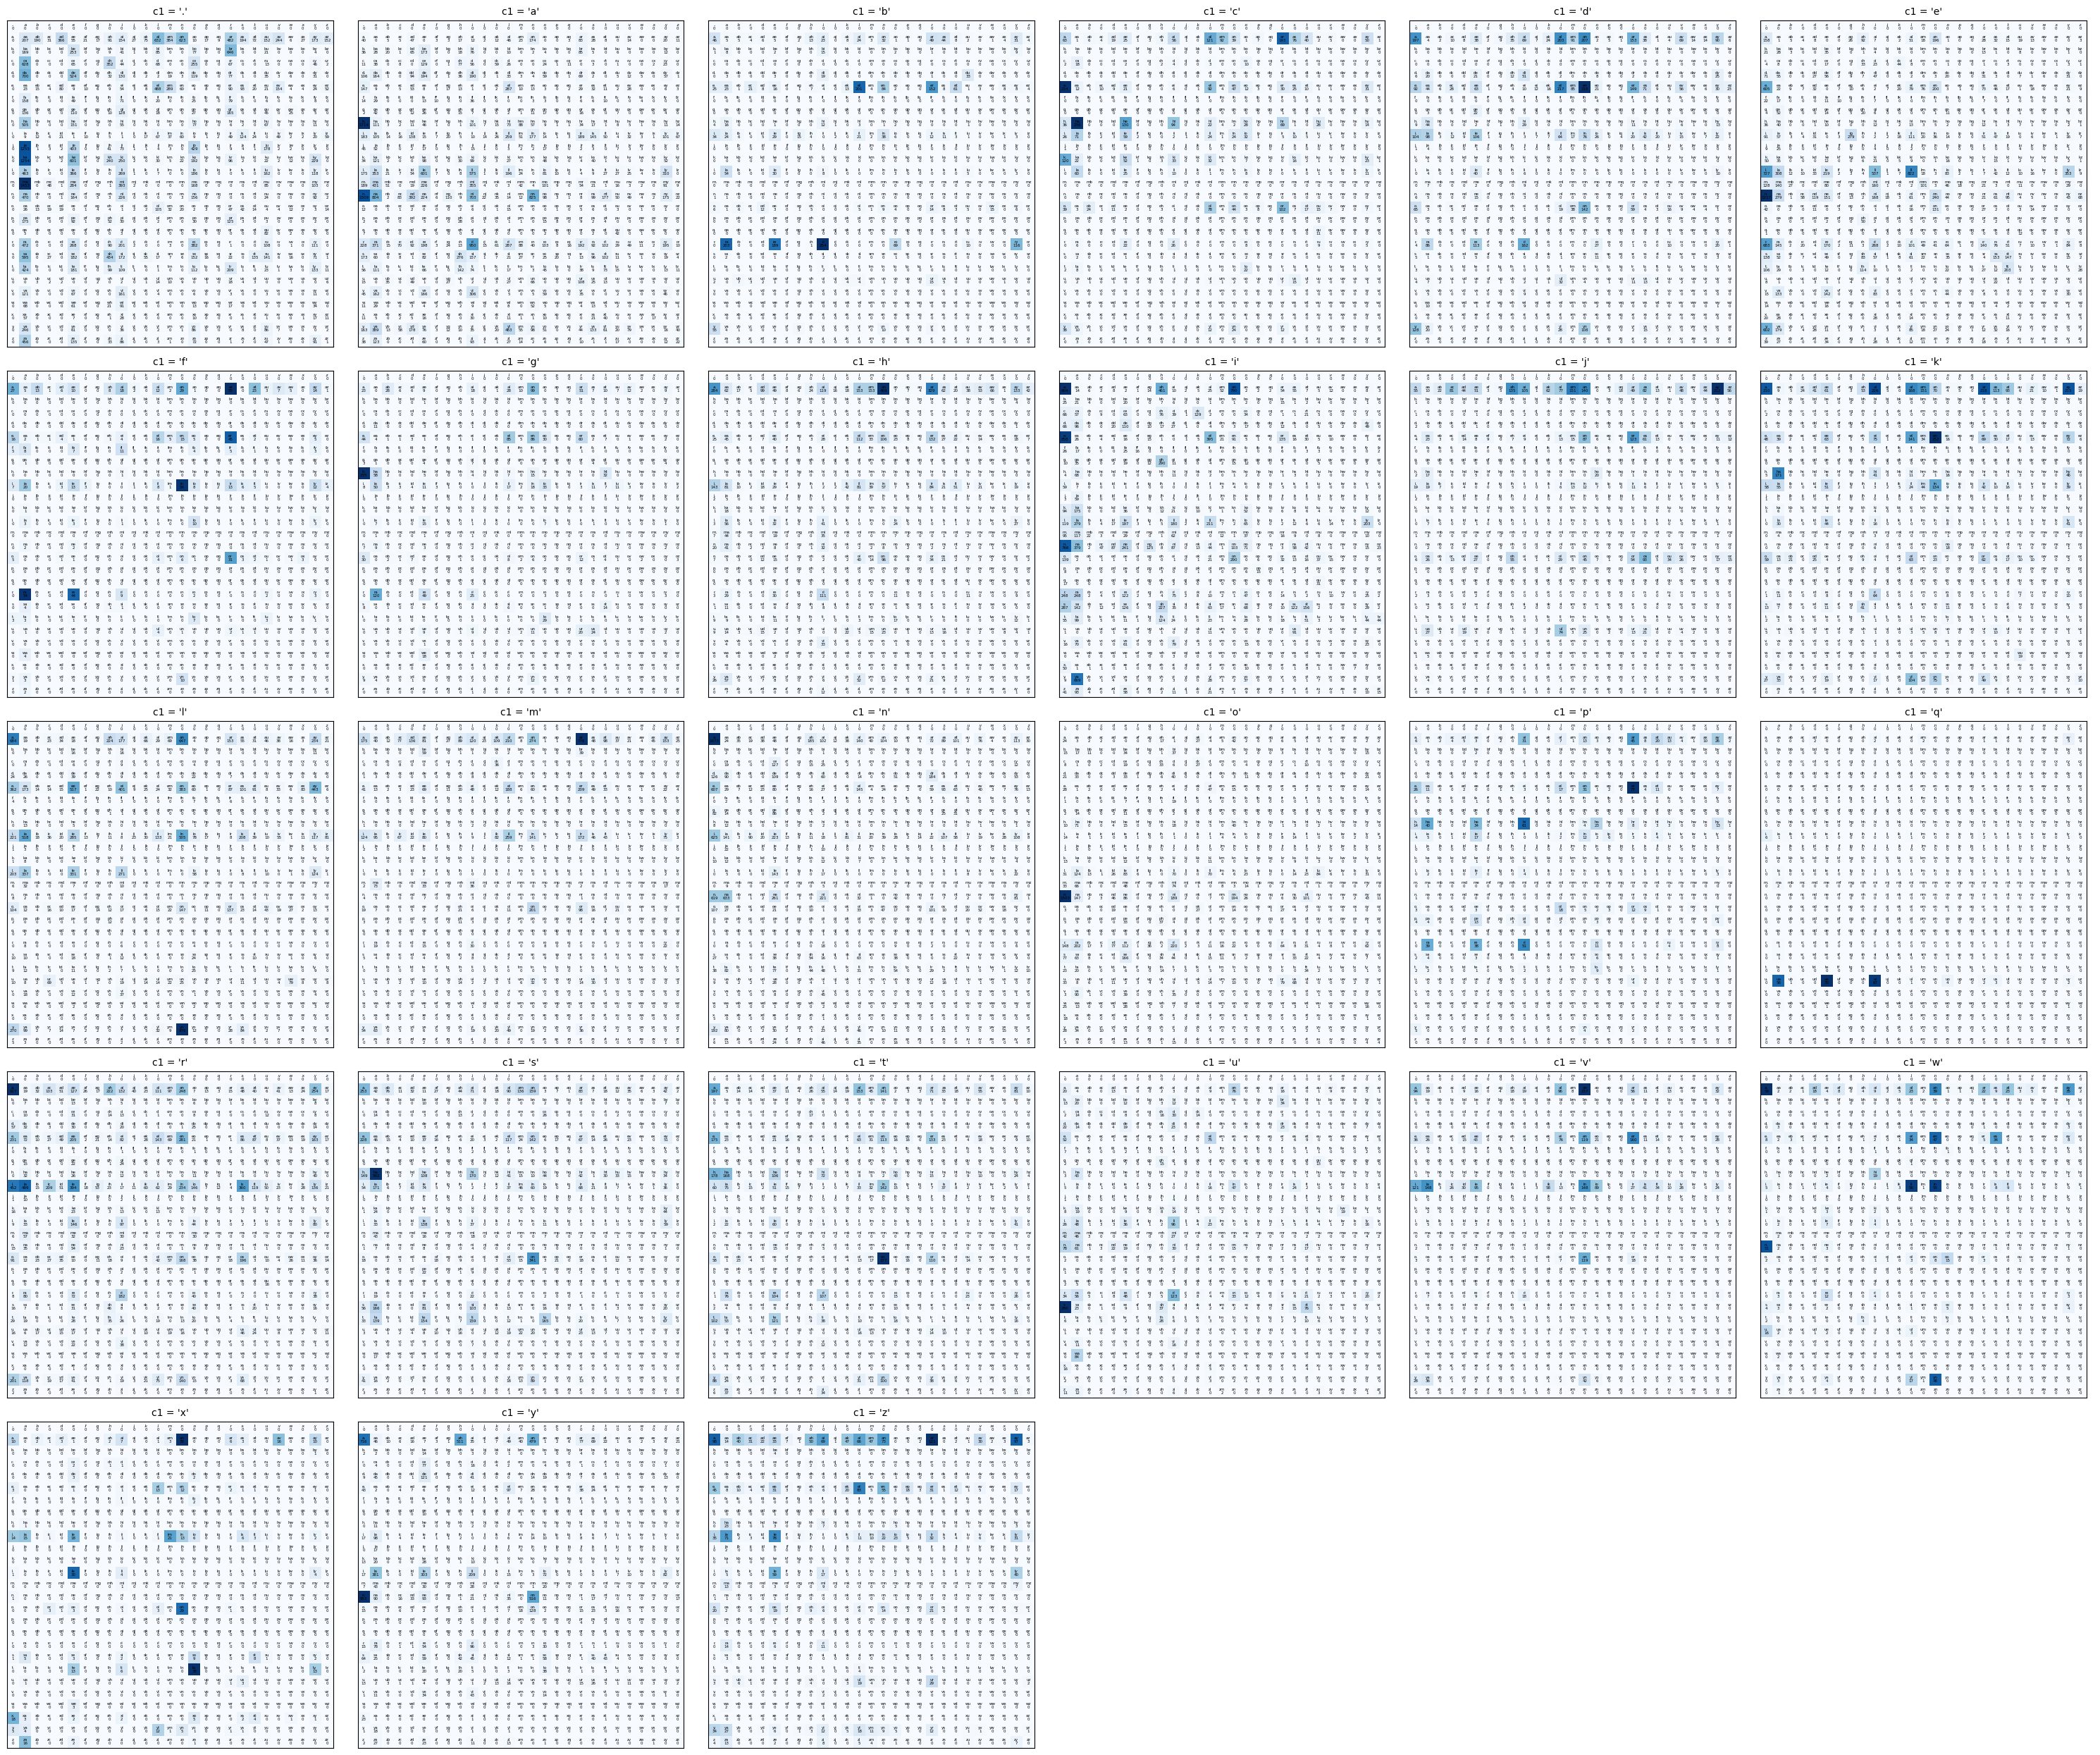

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(30, 25))
axes = axes.flatten()

for ix1 in range(27):
    ax = axes[ix1]
    ax.imshow(N[ix1], cmap='Blues')
    ax.set_title(f"c1 = '{num2char[ix1]}'", fontsize=10)
    for i in range(27):
        for j in range(27):
            chstr = num2char[i] + num2char[j]
            val = int(N[ix1, i, j].item())
            ax.text(j, i, chstr, ha='center', va='bottom', fontsize=4)
            ax.text(j, i, val, ha='center', va='top', fontsize=4)
    ax.set_xticks([])
    ax.set_yticks([])

for ix in range(27, 30):
    axes[ix].axis('off')

plt.tight_layout()
plt.show()

In [40]:
P = (N + 1).float()          # +1 for smoothing (avoids zero probs)
P = P / P.sum(dim=2, keepdim=True)  # normalize over the third character

In [42]:
P.shape

torch.Size([27, 27, 27])

In [43]:
P = (N + 1).float()
P = P / P.sum(dim=2, keepdim=True)

out = []
for i in range(20):
    ix1, ix2 = 0, 0  # start with two '.' tokens
    chars = []
    while True:
        p = P[ix1, ix2]  # shape (27,) — dist over next char given last two
        ix3 = torch.multinomial(p, num_samples=1, replacement=True).item()
        if ix3 == 0:  # end token
            break
        chars.append(num2char[ix3])
        ix1, ix2 = ix2, ix3  # slide the window forward
    out.append(''.join(chars))

out


['farvenn',
 'ayashealynnamakae',
 'via',
 '',
 'quel',
 'driettylashialohawt',
 'frey',
 'wyn',
 'oxleyma',
 'sam',
 'lyn',
 'oldssen',
 'elanes',
 'tiya',
 'xyley',
 'qfwnpmzod',
 'rix',
 'plcbqzy',
 'burie',
 'chka']